*Copyright (c) Meta Platforms, Inc. and affiliates.
Modified for JHU-Janelia bootcamp by Diptodip Deb.*

# Segmenting social fruit fly behavioral videos with DINOv3

This notebook demonstrates using [DINOv3](https://ai.meta.com/dinov3/) for video segmentation tracking
using a non-parametric method similar to
["Space-time correspondence as a contrastive random walk" (Jabri et al. 2020)](https://arxiv.org/abs/2006.14613).

Given:
- Video frames of two flies walking around an arena
- Instance segmentation masks for the two flies for *only* the first frame

We will extract patch features from each frame and use patch similarity
to propagate the ground-truth labels to all frames *without training anything*.

## Setup

Let's start by loading some pre-requisites, setting up the environment and checking the DINOv3 repository location. Note that you need to sign up to download DINOv3 and get the unique link to download the correct model yourself!

In [1]:
import datetime
import functools
import io
import logging
import math
import os
from pathlib import Path
import tarfile
import time
import urllib

!pip install lovely-tensors
import lovely_tensors
import matplotlib.pyplot as plt
!pip install mediapy
import mediapy as mp
import numpy as np
from sklearn.decomposition import PCA
from PIL import Image
import torch
import torch.nn.functional as F
import torchvision.transforms as TVT
import torchvision.transforms.functional as TVTF
from torch import Tensor, nn
from tqdm import tqdm

DISPLAY_HEIGHT = 200
lovely_tensors.monkey_patch()
torch.set_grad_enabled(False)
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 45.0 MB/s eta 0:00:00


## Model

We load the DINOv3 ViT-L model and get some attributes. Again, make sure to replace the line indicated with your own link to the DINOv3 weights for VITL16! You can try other DINO models with some slight changes to the code.

In [ ]:
# examples of available DINOv3 models:
MODEL_DINOV3_VITS = "dinov3_vits16"
MODEL_DINOV3_VITSP = "dinov3_vits16plus"
MODEL_DINOV3_VITB = "dinov3_vitb16"
MODEL_DINOV3_VITL = "dinov3_vitl16"
MODEL_DINOV3_VITHP = "dinov3_vith16plus"
MODEL_DINOV3_VIT7B = "dinov3_vit7b16"

# we take DINOv3 ViT-L
MODEL_NAME = MODEL_DINOV3_VITL
DINOV3_LOCATION = "facebookresearch/dinov3"

model = torch.hub.load(
    repo_or_dir=DINOV3_LOCATION,
    model=MODEL_NAME,
    source="github",
    weights=DINOV3_MODEL_URL, # FILL THIS IN WITH A STRING CONTAINING YOUR DINOV3 MODEL URL
)
model.to("cuda")
model.eval()

patch_size = model.patch_size
embed_dim = model.embed_dim
print(f"Patch size: {patch_size}")
print(f"Embedding dimension: {embed_dim}")
print(f"Peak GPU memory: {torch.cuda.max_memory_allocated() / 2**30:.1f} GB")

In [5]:
model # Visualize the structure of the model in the notebook

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-23): 24 x SelfAttentionBlock(
      (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=1024, out_features=3072, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    )
  )
  (norm)

We want to process one image at the time and get L2-normalized features.
Here is a wrapper to do just that.

In [6]:
@torch.compile(disable=True)
def forward(
    model: nn.Module,
    img: Tensor,  # [3, H, W] already normalized for the model
) -> Tensor:
    feats = model.get_intermediate_layers(img.unsqueeze(0), n=1, reshape=True)[0]  # [1, D, h, w]
    feats = feats.movedim(-3, -1)  # [1, h, w, D]
    feats = F.normalize(feats, dim=-1, p=2)
    return feats.squeeze(0)  # [h, w, D]

## Data

Here we load the video frames and the instance segmentation masks for the first frame.


This notebook assumes that the video has already been processed to extract individual frames as `.jpg` images in the current directory.
```txt
000001.jpg
000002.jpg
...
```

To run this notebook on your own `.mp4` video, use `ffmpeg` to extract frames as shown below for the example data:

In [7]:
!wget https://storage.googleapis.com/sleap-data/datasets/wt_gold.13pt/clips/talk_title_slide%4013150-14500.mp4 # Downloads example video of fruit flies
!mkdir -p ./frames # Creates a directory to store frames extracted from the video
!ffmpeg -i talk_title_slide@13150-14500.mp4 -start_number 0 ./frames/'%05d.jpg' # Converts the video to individual frames stored as JPEGs
!wget https://github.com/TuragaLab/jhu-janelia-ml-demo/blob/main/00000_labeled_manually.png # Downloads first labeled frame

--2025-08-27 13:20:16--  https://storage.googleapis.com/sleap-data/datasets/wt_gold.13pt/clips/talk_title_slide%4013150-14500.mp4
Resolving storage.googleapis.com (storage.googleapis.com)... 108.177.96.207, 108.177.119.207, 108.177.127.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|108.177.96.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45310983 (43M) [video/mp4]
Saving to: ‘talk_title_slide@13150-14500.mp4’

talk_title_slide@13 100%[===================>]  43.21M  21.6MB/s    in 2.0s    

2025-08-27 13:20:19 (21.6 MB/s) - ‘talk_title_slide@13150-14500.mp4’ saved [45310983/45310983]

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --

Number of frames: 64
Original size: width=1024, height=1024


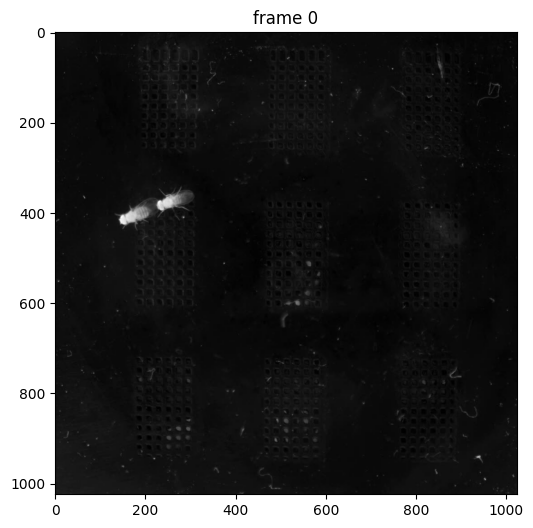

In [8]:
# `video_dir` is a directory of JPEG frames with filenames like `<frame_index>.jpg`
video_dir = "./frames"

# Scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))
# Loading only every other frame up to 128th frame to fit in Colab memory
frames = [Image.open(os.path.join(video_dir, frame_names[i])) for i in range(0, 128, 2)]

# Take a look the first video frame
frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

num_frames = len(frames)
print(f"Number of frames: {num_frames}")

original_width, original_height = frames[0].size
print(f"Original size: width={original_width}, height={original_height}")

Let's show four sample frames from the video to see the flies moving around the arena:

Frame 0,Frame 21,Frame 42,Frame 63

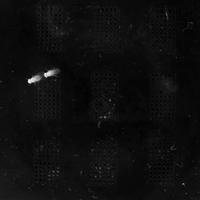
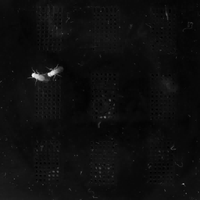
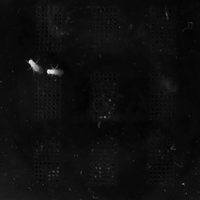
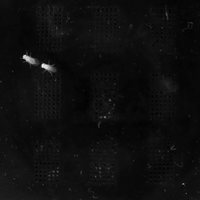

In [9]:
num_selected_frames = 4
selected_frames = np.linspace(0, num_frames - 1, num_selected_frames, dtype=int)

mp.show_images(
    [frames[int(i)] for i in selected_frames],
    titles=[f"Frame {i}" for i in selected_frames],
    height=DISPLAY_HEIGHT,
)

This notebook assumes that instance segmentation masks for the first frame are stored in a `.png` file:
- A value of `0` indicates the background.
- Object instances are represented by progressive contiguous `uint8` indices starting from `1`.

We created the example mask by hand, but [SAM 2]() would or other segmentation models would also work.

A function to visualize the masks as RGB is also provided.

Mask size: [1024, 1024]
Number of masks: 3


Frame,Mask

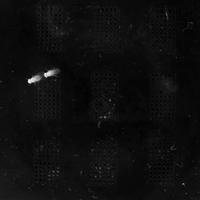
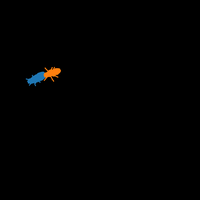

In [13]:
def mask_to_rgb(mask: np.ndarray | Tensor, num_masks: int) -> np.ndarray:
    if isinstance(mask, Tensor):
        mask = mask.cpu().numpy()

    # Exclude background
    background = mask == 0
    mask = mask - 1
    num_masks = num_masks - 1

    # Choose palette
    if num_masks <= 10:
        mask_rgb = plt.get_cmap("tab10")(mask)[..., :3]
    elif num_masks <= 20:
        mask_rgb = plt.get_cmap("tab20")(mask)[..., :3]
    else:
        mask_rgb = plt.get_cmap("gist_rainbow")(mask / (num_masks - 1))[..., :3]

    mask_rgb = (mask_rgb * 255).astype(np.uint8)
    mask_rgb[background, :] = 0
    return mask_rgb


def load_image_from_url(url: str) -> Image:
    with urllib.request.urlopen(url) as f:
        return Image.open(f)


first_mask_np = np.array(Image.open("00000_labeled_manually.png"))

mask_height, mask_width = first_mask_np.shape  # Abbreviated at [H', W']
print(f"Mask size: {[mask_height, mask_width]}")

num_masks = int(first_mask_np.max() + 1)  # Abbreviated as M
print(f"Number of masks: {num_masks}")

mp.show_images(
    [frames[0], mask_to_rgb(first_mask_np, num_masks)],
    titles=["Frame", "Mask"],
    height=DISPLAY_HEIGHT,
)

Time for some math! Input frames need to be resized to match the desired forward resolution and the model patch size.

The desired forward resolution refers to the _short side_ of the input.
If the desired resolution is not a multiple of the patch size, we simply round it up.
Then, we determine the _long side_ by maintaining the original aspect ratio as much as possible, but rounding up to the patch size as well.

We'll set up this resizing (plus normalization for images being input to the model) using torchvision transforms and test them out on the first frame.

In [14]:
class ResizeToMultiple(nn.Module):
    def __init__(self, short_side: int, multiple: int):
        super().__init__()
        self.short_side = short_side
        self.multiple = multiple

    def _round_up(self, side: float) -> int:
        return math.ceil(side / self.multiple) * self.multiple

    def forward(self, img):
        old_width, old_height = TVTF.get_image_size(img)
        if old_width > old_height:
            new_height = self._round_up(self.short_side)
            new_width = self._round_up(old_width * new_height / old_height)
        else:
            new_width = self._round_up(self.short_side)
            new_height = self._round_up(old_height * new_width / old_width)
        return TVTF.resize(img, [new_height, new_width], interpolation=TVT.InterpolationMode.BICUBIC)


SHORT_SIDE = 1024

transform = TVT.Compose(
    [
        ResizeToMultiple(short_side=SHORT_SIDE, multiple=patch_size),
        TVT.ToTensor(),
        TVT.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)
first_frame = transform(frames[0]).to("cuda")
print(f"First frame: {first_frame}")

_, frame_height, frame_width = first_frame.shape  # Abbreviated as [H, W]
feats_height, feats_width = frame_height // patch_size, frame_width // patch_size  # Abbreviated as [h, w]

First frame: tensor[3, 1024, 1024] n=3145728 (12Mb) x∈[-2.118, 2.640] μ=-1.743 σ=0.237 cuda:0


Label propagation happens at the output resolution of the model,
so we downsample the ground-truth masks of the first frame by the patch size and turn them into a one-hot probability map.

In [15]:
first_mask = torch.from_numpy(first_mask_np).to("cuda", dtype=torch.long)  # [H', W']
first_mask = F.interpolate(
    first_mask[None, None, :, :].float(),  # [1, 1, H', W']
    (feats_height, feats_width),
    mode="nearest-exact",
)[0, 0].long()  # [h, w]
print(f"First mask:  {first_mask}")

first_probs = F.one_hot(first_mask, num_masks).float()  # [h, w, M]
print(f"First probs: {first_probs}")

First mask:  tensor[64, 64] i64 n=4096 (32Kb) x∈[0, 2] μ=0.010 σ=0.130 cuda:0
First probs: tensor[64, 64, 3] n=12288 (48Kb) x∈[0., 1.000] μ=0.333 σ=0.471 cuda:0


## How it works

And now the fun part!

Label propagation takes as input:
- The features of the current frame, with shape `[h, w, D]`
- The features of the `t` context frames, with shape `[t, h, w, D]`
- The mask probabilities of `t` context frames, with shape `[t, h, w, M]`

For each patch of the current frame:
- We compute the cosine similarity with all context patches.
- We restrict the focus to a local neighborhood and select the top-k most similar context patches.
- We compute a weighted average of the mask probabilities of the selected patches to obtain a prediction for the mask probabilies of the current patch.

In [16]:
@torch.compile(disable=True)
def propagate(
    current_features: Tensor,  # [h", w", D], where h=h", w=w", and " stands for current
    context_features: Tensor,  # [t, h, w, D]
    context_probs: Tensor,  # [t, h, w, M]
    neighborhood_mask: Tensor,  # [h", w", h, w]
    topk: int,
    temperature: float,
) -> Tensor:
    t, h, w, M = context_probs.shape

    # Compute similarity current -> context
    dot = torch.einsum(
        "ijd, tuvd -> ijtuv",
        current_features,  # [h", w", D]
        context_features,  # [t, h, w, D]
    )  # [h", w", t, h, w]

    # Restrict focus to local neighborhood
    dot = torch.where(
        neighborhood_mask[:, :, None, :, :],  # [h", w", 1, h, w]
        dot,  # [h", w", t, h, w]
        -torch.inf,
    )

    # Select top-k patches inside the neighborhood
    dot = dot.flatten(2, -1).flatten(0, 1)  # [h"w", thw]
    k_th_largest = torch.topk(dot, dim=1, k=topk).values  # [h"w", k]
    dot = torch.where(
        dot >= k_th_largest[:, -1:],  # [h"w", thw]
        dot,  # [h"w", thw]
        -torch.inf,
    )

    # Propagate probabilities from context to current frame
    weights = F.softmax(dot / temperature, dim=1)  # [h"w", thw]
    current_probs = torch.mm(
        weights,  # [h"w", thw]
        context_probs.flatten(0, 2),  # [thw, M]
    )  # [h"w", M]

    # Propagated probs should already sum to 1, but just in case
    current_probs = current_probs / current_probs.sum(dim=1, keepdim=True)  # [h"w", M]

    return current_probs.unflatten(0, (h, w))  # [h", w", M]


@functools.lru_cache()
def make_neighborhood_mask(h: int, w: int, size: float, shape: str) -> Tensor:
    ij = torch.stack(
        torch.meshgrid(
            torch.arange(h, dtype=torch.float32, device="cuda"),
            torch.arange(w, dtype=torch.float32, device="cuda"),
            indexing="ij",
        ),
        dim=-1,
    )  # [h, w, 2]
    if shape == "circle":
        ord = 2
    elif shape == "square":
        ord = torch.inf
    else:
        raise ValueError(f"Invalid {shape=}")
    norm = torch.linalg.vector_norm(
        ij[:, :, None, None, :] - ij[None, None, :, :, :],  # [h", w", h, w, 2]
        ord=ord,
        dim=-1,
    )  # [h", w", h, w]
    mask = norm <= size  # [h", w", h, w] bool, True inside, False outside
    return mask

How does the neighborhood mask look like? Here's an example of the neighborhoods at two specific locations: (3, 14) and (20, 25).

"(3, 14)","(20, 25)"

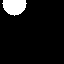
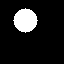

In [17]:
neighborhood_mask = make_neighborhood_mask(feats_height, feats_width, size=12, shape="circle")

mp.show_images(
    {f"{(i, j)}": neighborhood_mask[i, j].cpu().numpy() for i, j in [[3, 14], [20, 25]]},
    height=DISPLAY_HEIGHT,
)

To understand how it works, let's do it for one frame only.
The "context" contains only the first frame and the "current frame" is the second one.

In [27]:
torch._dynamo.maybe_mark_dynamic(first_frame, (1, 2))
first_feats = forward(model, first_frame)  # [h, w, D]
print(f"First feats:   {first_feats.shape}")

frame_idx = 1
current_frame_pil = frames[frame_idx]
current_frame = transform(current_frame_pil).to("cuda")  # [3, H, W]
torch._dynamo.maybe_mark_dynamic(current_frame, (1, 2))
current_feats = forward(model, current_frame)  # [h", w", D]
print(f"Current feats: {current_feats.shape}")

current_probs = propagate(
    current_feats,  # [h", w", D]
    context_features=first_feats.unsqueeze(0),  # [1, h, w, D]
    context_probs=first_probs.unsqueeze(0),  # [1, h, w, M]
    neighborhood_mask=neighborhood_mask,  # [h", w", h, w]
    topk=5,
    temperature=0.2,
)  # [h", w", M]
print(f"Current probs:  {current_probs}")
first_probs_before_upsample = current_probs # We'll use this later to visualize features

First feats:   torch.Size([64, 64, 1024])
Current feats: torch.Size([64, 64, 1024])
Current probs:  tensor[64, 64, 3] n=12288 (48Kb) x∈[0., 1.000] μ=0.333 σ=0.470 cuda:0


Then, we upsample the predicted probabilities and postprocess them.

Finally, we visualize:
- The first frame with its ground truth next to the second frame with the predicted masks.
- The per-mask probabilties predicted for the second frame.

First frame,Second frame
,

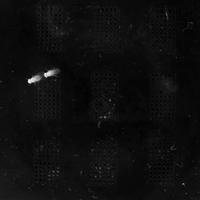
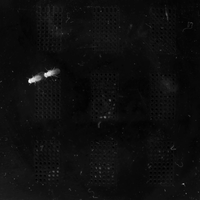
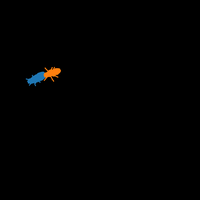
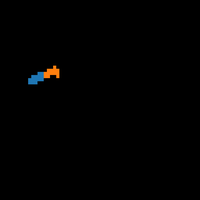

Mask 0,Mask 1,Mask 2

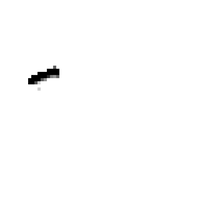
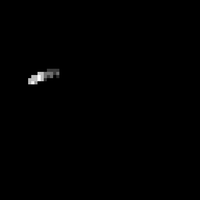
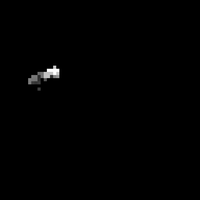

In [19]:
def postprocess_probs(
    probs: Tensor,  # [B, M, H', W']
) -> Tensor:
    vmin = probs.flatten(2, 3).min(dim=2).values  # [B, M]
    vmax = probs.flatten(2, 3).max(dim=2).values  # [B, M]
    probs = (probs - vmin[:, :, None, None]) / (vmax[:, :, None, None] - vmin[:, :, None, None])
    probs = torch.nan_to_num(probs, nan=0)
    return probs  # [B, M, H', W']


p = current_probs.movedim(-1, -3).unsqueeze(0)  # [1, M, h", w"]
p = F.interpolate(p, size=(mask_height, mask_width), mode="nearest")  # [1, M, H', W']
p = postprocess_probs(p).squeeze(0)  # [M, H', W']
current_pred_np = p.argmax(0).cpu().numpy()  # [H', W']
current_probs_np = p.cpu().numpy()  # [M, H', W']
del p

mp.show_images(
    [
        frames[0],
        current_frame_pil,
        mask_to_rgb(first_mask_np, num_masks),
        mask_to_rgb(current_pred_np, num_masks),
    ],
    titles=["First frame", "Second frame", "", ""],
    columns=2,
    height=DISPLAY_HEIGHT,
)

mp.show_images(current_probs_np, titles=[f"Mask {i}" for i in range(num_masks)], height=DISPLAY_HEIGHT)

## Process video

All clear? Time to do it for real!

This time we will process all frames, using a queue of context frames and a queue context mask probabilities.
The queues will contain a limited number of the most recent frames, determined by `max_context_length`.
The first frame is always included in the context and doesn't need to go in the queue.

Let's define all hyperparameters in one place.

In [20]:
MAX_CONTEXT_LENGTH = 7
NEIGHBORHOOD_SIZE = 12
NEIGHBORHOOD_SHAPE = "circle"
TOPK = 5
TEMPERATURE = 0.2

Let's go!

The predicted mask probabilities and the masks, at the original mask resolution, will be stored in `mask_predictions` and `mask_probabilities`.

In [21]:
mask_predictions = torch.zeros([num_frames, mask_height, mask_width], dtype=torch.uint8)  # [T, H', W']
mask_predictions[0, :, :] = torch.from_numpy(first_mask_np)

mask_probabilities = torch.zeros([num_frames, num_masks, mask_height, mask_width])  # [T, M, H', W']
mask_probabilities[0, :, :, :] = F.one_hot(torch.from_numpy(first_mask_np).long(), num_masks).movedim(-1, -3)

features_queue: list[Tensor] = []
probs_queue: list[Tensor] = []

neighborhood_mask = make_neighborhood_mask(
    feats_height,
    feats_width,
    size=NEIGHBORHOOD_SIZE,
    shape=NEIGHBORHOOD_SHAPE,
)  # [h", w", h, w]

start = time.perf_counter()
for frame_idx in tqdm(range(1, num_frames), desc="Processing"):
    # Extract features for the current frame
    current_frame_pil = frames[frame_idx]
    current_frame = transform(current_frame_pil).to("cuda")  # [3, H, W]
    torch._dynamo.maybe_mark_dynamic(current_frame, (1, 2))
    current_feats = forward(model, current_frame)  # [h", w", D]

    # Prepare the context, marking the time and mask dimensions as dynamic for torch compile
    context_feats = torch.stack([first_feats, *features_queue], dim=0)  # [1+len(queue), h, w, D]
    context_probs = torch.stack([first_probs, *probs_queue], dim=0)  # [1+len(queue), h, w, M]
    torch._dynamo.maybe_mark_dynamic(context_feats, 0)
    torch._dynamo.maybe_mark_dynamic(context_probs, (0, 3))

    # Propagate segmentation probs from context frames
    current_probs = propagate(
        current_feats,
        context_feats,
        context_probs,
        neighborhood_mask,
        TOPK,
        TEMPERATURE,
    )  # [h", w", M]

    # Update queues with current features and probs
    features_queue.append(current_feats)
    probs_queue.append(current_probs)
    if len(features_queue) > MAX_CONTEXT_LENGTH:
        features_queue.pop(0)
    if len(probs_queue) > MAX_CONTEXT_LENGTH:
        probs_queue.pop(0)

    # Upsample and postprocess segmentation probs, argmax to obtain a prediction
    current_probs = F.interpolate(
        current_probs.movedim(-1, -3)[None, :, :, :],
        size=(mask_height, mask_width),
        mode="nearest",
    )  # [1, M, H', W']
    current_probs = postprocess_probs(current_probs)  # [1, M, H', W']
    current_probs = current_probs.squeeze(0)
    mask_probabilities[frame_idx, :, :, :] = current_probs
    pred = torch.argmax(current_probs, dim=0).to(dtype=torch.uint8)  # [H', W']
    mask_predictions[frame_idx, :, :] = pred  # [H', W']

torch.cuda.synchronize()
end = time.perf_counter()
print(f"Processing time:    {datetime.timedelta(seconds=round(end - start))}")
print(f"Mask probabilities: {mask_probabilities}")
print(f"Mask predictions:   {mask_predictions}")

Processing: 100%|██████████| 63/63 [01:37<00:00,  1.54s/it]


Processing time:    0:01:37
Mask probabilities: tensor[64, 3, 1024, 1024] n=201326592 (0.8Gb) x∈[0., 1.000] μ=0.335 σ=0.470
Mask predictions:   tensor[64, 1024, 1024] u8 n=67108864 (64Mb) x∈[0, 2] μ=0.011 σ=0.135


Let's visualize a few frames and a video of the result.

Frame 0,Frame 21,Frame 42,Frame 63
,,,

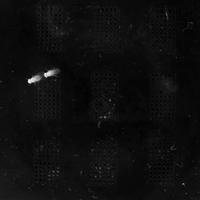
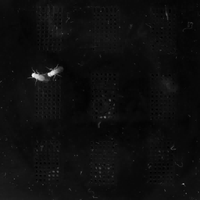
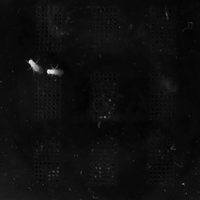
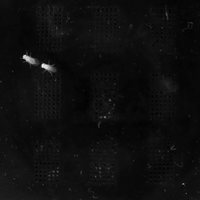
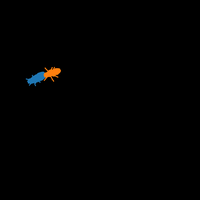
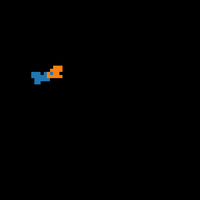
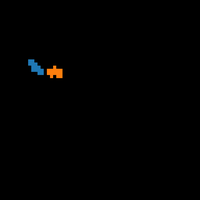
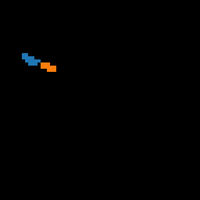

Frame 0,Frame 21,Frame 42,Frame 63
,,,

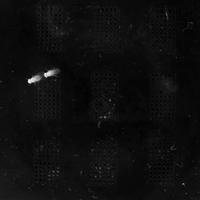
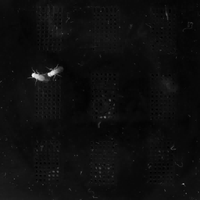
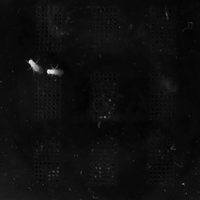
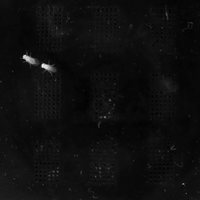
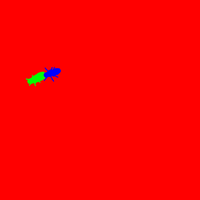
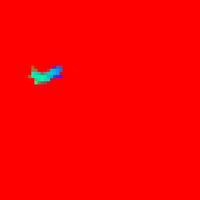
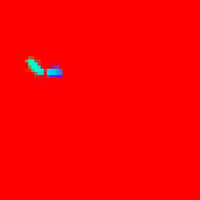
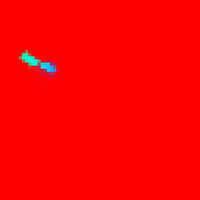

In [22]:
import mediapy as mp

mp.show_images(
    [frames[i].convert("RGB") for i in selected_frames]
    + [mask_to_rgb(mask_predictions[i], num_masks) for i in selected_frames],
    titles=[f"Frame {i}" for i in selected_frames] + [""] * len(selected_frames),
    columns=len(selected_frames),
    height=DISPLAY_HEIGHT,
)

mp.show_images(
    [frames[i].convert("RGB") for i in selected_frames]
    + [mask_probabilities[i, -3:, ...].permute(1, 2, 0).numpy() for i in selected_frames],
    titles=[f"Frame {i}" for i in selected_frames] + [""] * len(selected_frames),
    columns=len(selected_frames),
    height=DISPLAY_HEIGHT,
)

# Exploring the features learned by DINO

### Extracting Foreground Patches
We find the patches with positive classifier output, in order to fit a PCA only on the foreground object (the first fly).


In [48]:
fly1_selection = first_probs_before_upsample[..., 1].view(-1) > 0.5
fly1_patches = (first_feats.reshape(-1, 1024))[fly1_selection]

### Fitting the PCA
We use 3 components, and use whitening.

In [49]:
pca = PCA(n_components=3, whiten=True)
pca.fit(fly1_patches.cpu().numpy())

PCA(n_components=3, whiten=True)

### Applying the PCA, and Masking Background
Finally, we project the features using the PCA, and apply a mask to set the background to black. How do you interpret the features?

/tmp/ipython-input-3274786547.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  projected_image *= (first_probs_before_upsample[..., 1].unsqueeze(0).cpu().numpy() > 0.5)


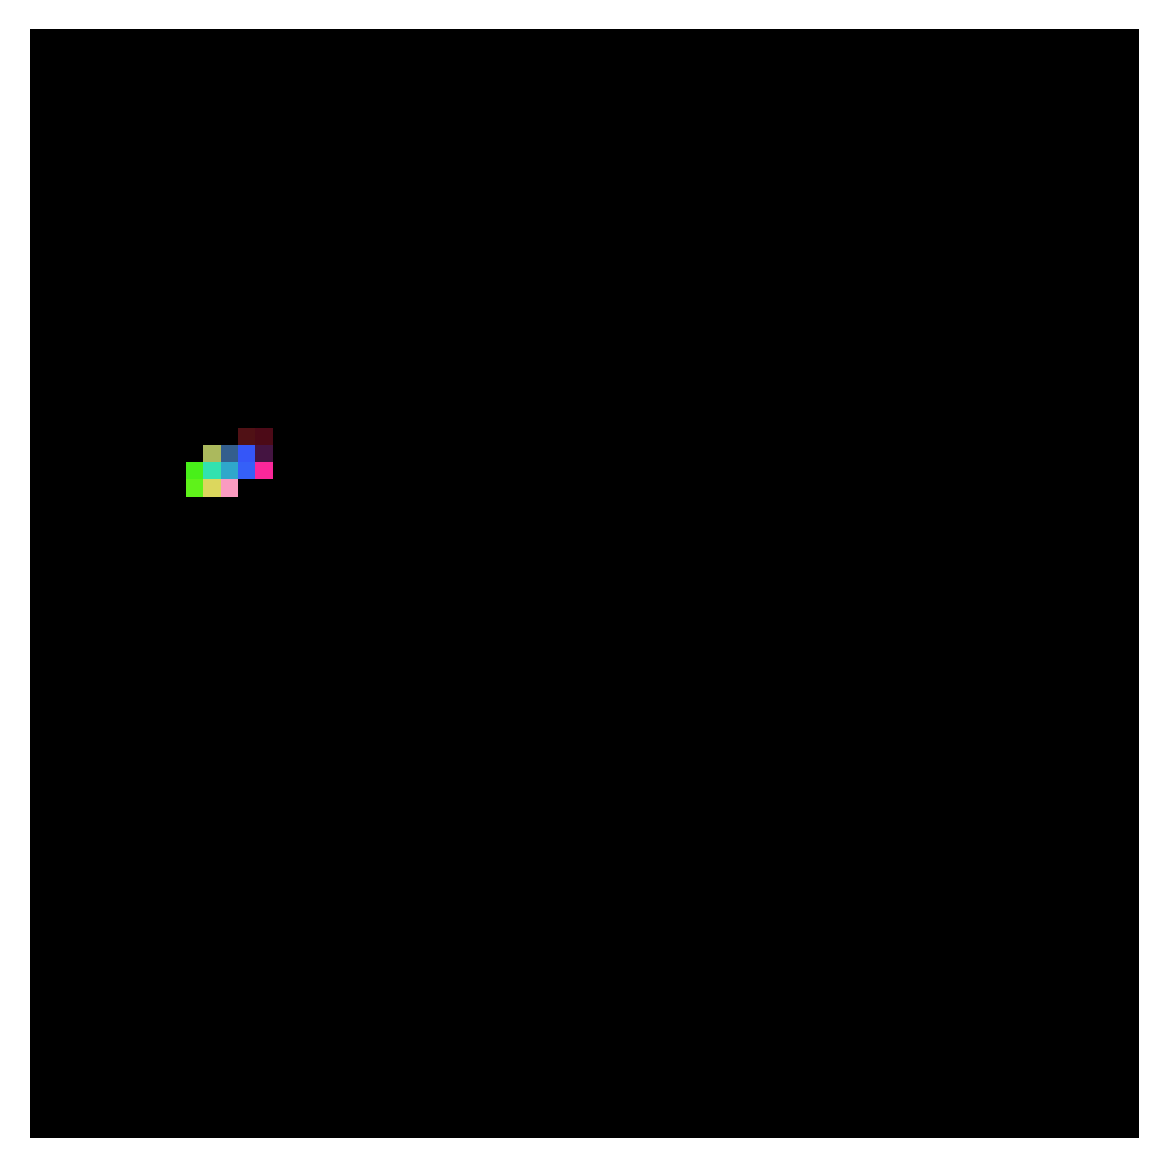

In [50]:
# apply the PCA, and then reshape
projected_image = torch.from_numpy(pca.transform(first_feats.reshape(-1, 1024).cpu().numpy())).view(64, 64, 3)

# multiply by 2.0 and pass through a sigmoid to get vibrant colors
projected_image = torch.nn.functional.sigmoid(projected_image.mul(2.0)).permute(2, 0, 1)

# mask the background using the fg_score_mf
projected_image *= (first_probs_before_upsample[..., 1].unsqueeze(0).cpu().numpy() > 0.5)

# enjoy
plt.figure(dpi=300)
plt.imshow(projected_image.permute(1, 2, 0))
plt.axis('off')
plt.show()

Now let's do the same but for the second fly!

/tmp/ipython-input-1453804042.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  projected_image *= (first_probs_before_upsample[..., 2].unsqueeze(0).cpu().numpy() > 0.5)


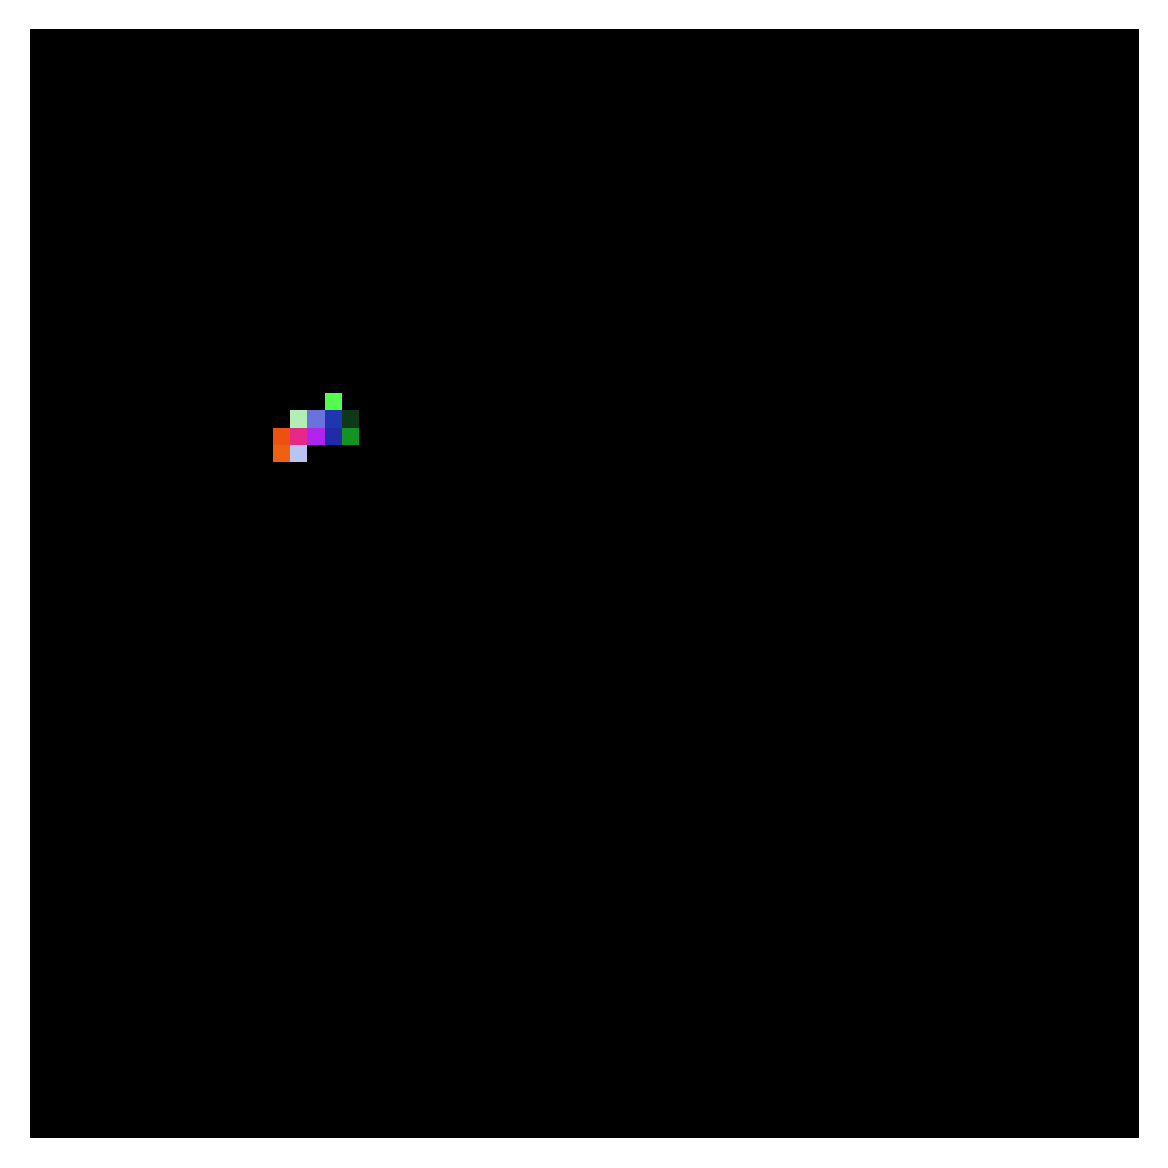

In [51]:
fly2_selection = first_probs_before_upsample[..., 2].view(-1) > 0.5
fly2_patches = (first_feats.reshape(-1, 1024))[fly2_selection]
pca = PCA(n_components=3, whiten=True)
pca.fit(fly2_patches.cpu().numpy())
# apply the PCA, and then reshape
projected_image = torch.from_numpy(pca.transform(first_feats.reshape(-1, 1024).cpu().numpy())).view(64, 64, 3)

# multiply by 2.0 and pass through a sigmoid to get vibrant colors
projected_image = torch.nn.functional.sigmoid(projected_image.mul(2.0)).permute(2, 0, 1)

# mask the background using the fg_score_mf
projected_image *= (first_probs_before_upsample[..., 2].unsqueeze(0).cpu().numpy() > 0.5)

# enjoy
plt.figure(dpi=300)
plt.imshow(projected_image.permute(1, 2, 0))
plt.axis('off')
plt.show()

Do you agree with DINOv3? Why do you think the features look different for the two flies?

# Conclusion

This notebook showed how to use DINOv3 for video segmentation tracking.
It should be fairly straightforward to run it to your own video and masks.
The notebook hyperparameters can also be adjusted to see the effect on the results.

You can think of a few extensions from here:

1. What happens if the frame rate of the video is really low? You can try this by subsampling the demo video frames even further. How would you try to solve this problem?
2. The input mask we started with is very poor. How much better can you make the results with better masks? Do you need to use a different patch size to make this happen?

If you want to run this model on your own computer, here are some notes on GPU memory usage from the original demo by Meta:
- The ViT-L model takes approximately 1.1 GB to load.
- The similarity matrix `dot` inside `propagate()` can get pretty big,
  especially at higher resolution and longer context length.

To reduce memory usage and increase speed, the notebook is already set up to work with `torch.compile()`.
In particular, note the use of `torch._dynamo.maybe_mark_dynamic()` to mark a few dimensions as dynamic
to avoid too many recompilations. To enable compilation, just set `disable` to `False` in the
`@torch.compile()` decorators for the `propagate()` and `forward()` functions.

If you are low on memory, it also possible to use a smaller model and
reduce the forward resolution, but tracking results will look worse.

In [ ]:
print(f"Peak GPU memory: {torch.cuda.max_memory_allocated() / 2**30:.1f} GB")

Peak GPU memory: 3.6 GB
